In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\prith\Restaurant-Data-Analysis\data\Dataset .csv")

df_clean = df.copy()
df_clean["Cuisines"] = df_clean["Cuisines"].fillna("Unknown")

df_clean.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:

# Count the cuisine labels in the dataset

cuisine_counts = df_clean["Cuisines"].value_counts()

print("Number of unique cuisine labels:", df_clean["Cuisines"].nunique())
display(cuisine_counts.head(15))

Number of unique cuisine labels: 1826


Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
South Indian                      112
Bakery, Fast Food                 108
Name: count, dtype: int64

In [3]:

# Count how frequently each cuisine label appears

print("Total unique cuisine labels:", df_clean["Cuisines"].nunique())

print("\nCuisine labels appearing only once:")
print((cuisine_counts == 1).sum())

print("\nCuisine labels appearing 10 times or fewer:")
print((cuisine_counts <= 10).sum())

print("\nMost common 20 cuisine labels:")
display(cuisine_counts.head(20))

Total unique cuisine labels: 1826

Cuisine labels appearing only once:
1278

Cuisine labels appearing 10 times or fewer:
1732

Most common 20 cuisine labels:


Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
South Indian                      112
Bakery, Fast Food                 108
Chinese, North Indian             105
Mughlai                           103
Ice Cream, Desserts                83
North Indian, Fast Food            74
Ice Cream                          74
Name: count, dtype: int64

In [4]:

print("Total unique cuisine labels:", df_clean["Cuisines"].nunique())
print("Labels appearing only once:", (cuisine_counts == 1).sum())
print("Labels appearing 10 times or fewer:", (cuisine_counts <= 10).sum())

Total unique cuisine labels: 1826
Labels appearing only once: 1278
Labels appearing 10 times or fewer: 1732


In [5]:

# Split cuisine combinations into individual cuisine names

individual_cuisines = (
    df_clean["Cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

individual_cuisine_counts = individual_cuisines.value_counts()

print("Number of individual cuisine categories:",
      individual_cuisine_counts.size)

display(individual_cuisine_counts.head(20))

Number of individual cuisine categories: 146


Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Thai             234
Asian            233
Beverages        229
Ice Cream        226
Mexican          181
Name: count, dtype: int64

In [6]:

# Create a target label using the first cuisine listed

cuisine_df = df_clean.copy()

cuisine_df["Main Cuisine"] = (
    cuisine_df["Cuisines"]
    .str.split(",")
    .str[0]
    .str.strip()
)

print("Number of main-cuisine categories:",
      cuisine_df["Main Cuisine"].nunique())

display(cuisine_df["Main Cuisine"].value_counts().head(20))

Number of main-cuisine categories: 120


Main Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64

In [7]:

# Identify the 10 most frequent main cuisines

top_cuisines = (
    cuisine_df["Main Cuisine"]
    .value_counts()
    .head(10)
    .index
)

print("Selected cuisine categories:")
print(top_cuisines.tolist())

Selected cuisine categories:
['North Indian', 'Chinese', 'Fast Food', 'Bakery', 'Cafe', 'American', 'South Indian', 'Mithai', 'Street Food', 'Continental']


In [8]:

# Keep only the 10 selected cuisine categories

classification_df = cuisine_df[
    cuisine_df["Main Cuisine"].isin(top_cuisines)
].copy()

print("Filtered dataset shape:", classification_df.shape)

print("\nRestaurants in each selected cuisine:")
display(classification_df["Main Cuisine"].value_counts())

Filtered dataset shape: (7014, 22)

Restaurants in each selected cuisine:


Main Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Name: count, dtype: int64

In [9]:

# Select input features and target

features = [
    "Country Code",
    "City",
    "Average Cost for two",
    "Price range",
    "Has Table booking",
    "Has Online delivery",
    "Aggregate rating",
    "Votes"
]

X_cuisine = classification_df[features].copy()
y_cuisine = classification_df["Main Cuisine"].copy()

print("Feature shape:", X_cuisine.shape)
print("Target shape:", y_cuisine.shape)

display(X_cuisine.head())

Feature shape: (7014, 8)
Target shape: (7014,)


,Country Code,City,Average Cost for two,Price range,Has Table booking,Has Online delivery,Aggregate rating,Votes
5,162,Mandaluyong City,1000,3,No,No,4.4,336
11,162,Pasig City,900,3,Yes,No,4.2,488
15,162,Santa Rosa,800,3,No,No,3.6,29
18,162,Taguig City,600,2,No,No,4.5,118
19,162,Taguig City,1500,4,Yes,No,4.4,392


In [10]:

from sklearn.model_selection import train_test_split

X_train_cuisine, X_test_cuisine, y_train_cuisine, y_test_cuisine = train_test_split(
    X_cuisine,
    y_cuisine,
    test_size=0.2,
    random_state=42,
    stratify=y_cuisine
)

print("Training features:", X_train_cuisine.shape)
print("Testing features:", X_test_cuisine.shape)
print("Training target:", y_train_cuisine.shape)
print("Testing target:", y_test_cuisine.shape)

Training features: (5611, 8)
Testing features: (1403, 8)
Training target: (5611,)
Testing target: (1403,)


In [11]:

# Separate numeric and categorical columns

numeric_features = [
    "Country Code",
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

categorical_features = [
    "City",
    "Has Table booking",
    "Has Online delivery"
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Country Code', 'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']
Categorical features: ['City', 'Has Table booking', 'Has Online delivery']


In [12]:

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Process numeric columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Process categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [13]:

from sklearn.ensemble import RandomForestClassifier

# Create the complete classification pipeline
cuisine_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=1,
        min_samples_leaf=3
    ))
])

print("Cuisine classification model created!")

Cuisine classification model created!


In [14]:

# Train the cuisine classification model

cuisine_model.fit(X_train_cuisine, y_train_cuisine)

print("Cuisine classification model trained successfully!")


Cuisine classification model trained successfully!


In [15]:

# Predict cuisine categories for the test dataset

y_pred_cuisine = cuisine_model.predict(X_test_cuisine)

print("Predictions completed!")
print("Number of predictions:", len(y_pred_cuisine))

# Compare a few actual and predicted labels
comparison = pd.DataFrame({
    "Actual Cuisine": y_test_cuisine.values,
    "Predicted Cuisine": y_pred_cuisine
})

display(comparison.head(10))

Predictions completed!
Number of predictions: 1403


,Actual Cuisine,Predicted Cuisine
0,North Indian,North Indian
1,Chinese,Bakery
2,Mithai,North Indian
3,North Indian,North Indian
4,North Indian,North Indian
5,North Indian,North Indian
6,North Indian,North Indian
7,North Indian,North Indian
8,North Indian,North Indian
9,Chinese,North Indian


In [16]:

from sklearn.metrics import accuracy_score, classification_report

# Calculate overall accuracy
accuracy = accuracy_score(y_test_cuisine, y_pred_cuisine)

print("Classification Accuracy:", round(accuracy, 4))

# Detailed performance for each cuisine
print("\nClassification Report:")
print(classification_report(
    y_test_cuisine,
    y_pred_cuisine,
    zero_division=0
))

Classification Accuracy: 0.4633

Classification Report:
              precision    recall  f1-score   support

    American       0.68      0.54      0.60        56
      Bakery       0.22      0.03      0.06       124
        Cafe       0.47      0.16      0.24       123
     Chinese       0.00      0.00      0.00       171
 Continental       0.00      0.00      0.00        47
   Fast Food       0.29      0.04      0.07       135
      Mithai       1.00      0.08      0.15        49
North Indian       0.46      0.97      0.62       599
South Indian       0.00      0.00      0.00        52
 Street Food       0.44      0.17      0.25        47

    accuracy                           0.46      1403
   macro avg       0.36      0.20      0.20      1403
weighted avg       0.36      0.46      0.34      1403



In [17]:

# Count how often the model predicted each cuisine

print("Actual cuisine distribution:")
display(y_test_cuisine.value_counts())

print("\nPredicted cuisine distribution:")
display(pd.Series(y_pred_cuisine).value_counts())

Actual cuisine distribution:


Main Cuisine
North Indian    599
Chinese         171
Fast Food       135
Bakery          124
Cafe            123
American         56
South Indian     52
Mithai           49
Continental      47
Street Food      47
Name: count, dtype: int64


Predicted cuisine distribution:


North Indian    1256
American          44
Cafe              43
Bakery            18
Street Food       18
Fast Food         17
Mithai             4
Chinese            3
Name: count, dtype: int64

In [18]:

cuisine_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=3,
        class_weight="balanced"
    ))
])

In [19]:

cuisine_model.fit(X_train_cuisine, y_train_cuisine)

y_pred_cuisine = cuisine_model.predict(X_test_cuisine)

print("Model retrained with balanced class weights.")

Model retrained with balanced class weights.


In [20]:

from sklearn.metrics import accuracy_score, classification_report

balanced_accuracy = accuracy_score(
    y_test_cuisine,
    y_pred_cuisine
)

print("Balanced Model Accuracy:", round(balanced_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_cuisine,
    y_pred_cuisine,
    zero_division=0
))

Balanced Model Accuracy: 0.2687

Classification Report:
              precision    recall  f1-score   support

    American       0.46      0.66      0.54        56
      Bakery       0.19      0.25      0.22       124
        Cafe       0.25      0.43      0.32       123
     Chinese       0.20      0.12      0.15       171
 Continental       0.17      0.74      0.27        47
   Fast Food       0.21      0.20      0.21       135
      Mithai       0.18      0.59      0.28        49
North Indian       0.72      0.20      0.31       599
South Indian       0.11      0.23      0.15        52
 Street Food       0.17      0.30      0.22        47

    accuracy                           0.27      1403
   macro avg       0.27      0.37      0.27      1403
weighted avg       0.43      0.27      0.27      1403



In [21]:

print("Predicted cuisine distribution:")
display(pd.Series(y_pred_cuisine).value_counts())

Predicted cuisine distribution:


Cafe            212
Continental     210
North Indian    166
Bakery          161
Mithai          159
Fast Food       128
South Indian    107
Chinese          99
Street Food      81
American         80
Name: count, dtype: int64

In [22]:
import pandas as pd

classification_comparison_df = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Balanced Random Forest",
        "Balanced Logistic Regression",
        "Oversampled Random Forest"
    ],
    "Accuracy": [
        0.4633,
        0.2687,
        0.1974,
        0.2958
    ],
    "Macro F1-score": [
        0.20,
        0.27,
        0.1851,
        0.2815
    ],
    "Weighted F1-score": [
        0.34,
        0.27,
        0.1906,
        0.3089
    ]
})

classification_comparison_df
classification_comparison_df.round(4)

,Model,Accuracy,Macro F1-score,Weighted F1-score
0,Original Random Forest,0.4633,0.2000,0.3400
1,Balanced Random Forest,0.2687,0.2700,0.2700
2,Balanced Logistic Regression,0.1974,0.1851,0.1906
3,Oversampled Random Forest,0.2958,0.2815,0.3089


In [23]:

from sklearn.linear_model import LogisticRegression

logistic_cuisine_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Logistic Regression model created!")

Logistic Regression model created!


In [24]:

logistic_cuisine_model.fit(
    X_train_cuisine,
    y_train_cuisine
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [25]:

y_pred_logistic = logistic_cuisine_model.predict(
    X_test_cuisine
)

print("Predictions completed:", len(y_pred_logistic))

Predictions completed: 1403


In [26]:

from sklearn.metrics import accuracy_score, classification_report, f1_score

logistic_accuracy = accuracy_score(
    y_test_cuisine,
    y_pred_logistic
)

logistic_macro_f1 = f1_score(
    y_test_cuisine,
    y_pred_logistic,
    average="macro",
    zero_division=0
)

logistic_weighted_f1 = f1_score(
    y_test_cuisine,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Accuracy:", round(logistic_accuracy, 4))
print("Macro F1-score:", round(logistic_macro_f1, 4))
print("Weighted F1-score:", round(logistic_weighted_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test_cuisine,
    y_pred_logistic,
    zero_division=0
))

Logistic Regression Accuracy: 0.1974
Macro F1-score: 0.1851
Weighted F1-score: 0.1906

Classification Report:
              precision    recall  f1-score   support

    American       0.23      0.75      0.35        56
      Bakery       0.13      0.10      0.11       124
        Cafe       0.20      0.33      0.25       123
     Chinese       0.14      0.04      0.06       171
 Continental       0.15      0.53      0.24        47
   Fast Food       0.28      0.19      0.22       135
      Mithai       0.09      0.45      0.14        49
North Indian       0.66      0.13      0.22       599
South Indian       0.05      0.08      0.06        52
 Street Food       0.12      0.43      0.19        47

    accuracy                           0.20      1403
   macro avg       0.21      0.30      0.19      1403
weighted avg       0.38      0.20      0.19      1403



In [27]:

final_comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Balanced Random Forest",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        0.4633,
        0.2687,
        0.1974
    ],
    "Macro F1-score": [
        0.20,
        0.27,
        0.1851
    ],
    "Weighted F1-score": [
        0.34,
        0.27,
        0.1906
    ]
})

display(final_comparison)


,Model,Accuracy,Macro F1-score,Weighted F1-score
0,Original Random Forest,0.4633,0.2000,0.3400
1,Balanced Random Forest,0.2687,0.2700,0.2700
2,Balanced Logistic Regression,0.1974,0.1851,0.1906


In [28]:
print(type(cuisine_model))

<class 'sklearn.pipeline.Pipeline'>


In [29]:
print(type(cuisine_model))
print(cuisine_model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Country Code',
                                                   'Average Cost for two',
                                                   'Price range',
                                                   'Aggregate rating',
                                                   'Votes']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                         

In [30]:
print(hasattr(cuisine_model, "classes_"))
print(hasattr(cuisine_model[-1], "classes_"))

True
True


In [31]:
cuisine_model.fit(X_train_cuisine, y_train_cuisine)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](10,)","['American','Bakery','Cafe',...,'North Indian','South Indian', 'Street Food']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Country Code','City','Average Cost for two',...,'Has Online delivery', 'Aggregate rating','Votes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the out

In [32]:
print(cuisine_model.classes_)

['American' 'Bakery' 'Cafe' 'Chinese' 'Continental' 'Fast Food' 'Mithai'
 'North Indian' 'South Indian' 'Street Food']


In [33]:
y_pred_balanced = cuisine_model.predict(X_test_cuisine)

In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [35]:
class_labels = cuisine_model.classes_

cm = confusion_matrix(
    y_test_cuisine,
    y_pred_balanced,
    labels=class_labels
)

print(cm)

[[ 37   1   5   1   7   2   0   2   1   0]
 [  0  31  13   9   5  14  17  11  10  14]
 [ 13  11  53   6  19   3   6   7   4   1]
 [  4  23  27  20  27  18  13  21  11   7]
 [  0   0   9   2  35   0   1   0   0   0]
 [  6  22  12  11   7  27  21   3  17   9]
 [  0   2   1   1   0   2  29   0   4  10]
 [ 19  60  82  44 108  52  44 119  47  24]
 [  1   6   7   3   2   7  10   2  12   2]
 [  0   5   3   2   0   3  18   1   1  14]]


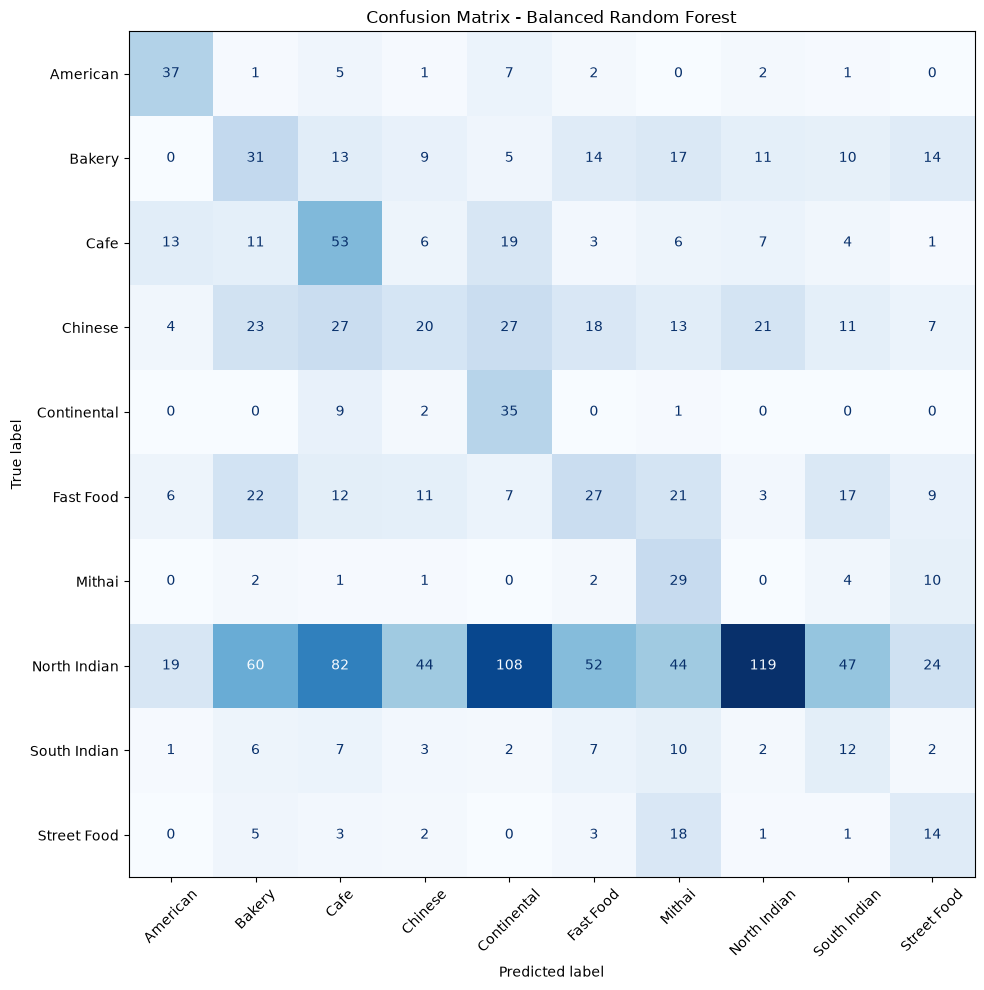

In [36]:
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Balanced Random Forest")
plt.tight_layout()
plt.show()

In [37]:
import numpy as np

correct_predictions = np.diag(cm)
actual_counts = cm.sum(axis=1)

class_accuracy = correct_predictions / actual_counts

for cuisine, correct, total, score in zip(
    class_labels,
    correct_predictions,
    actual_counts,
    class_accuracy
):
    print(f"{cuisine}: {correct}/{total} correct ({score:.1%})")

American: 37/56 correct (66.1%)
Bakery: 31/124 correct (25.0%)
Cafe: 53/123 correct (43.1%)
Chinese: 20/171 correct (11.7%)
Continental: 35/47 correct (74.5%)
Fast Food: 27/135 correct (20.0%)
Mithai: 29/49 correct (59.2%)
North Indian: 119/599 correct (19.9%)
South Indian: 12/52 correct (23.1%)
Street Food: 14/47 correct (29.8%)


In [38]:

import pandas as pd
import numpy as np

# Copy the matrix so we don't change the original
off_diagonal = cm.copy()

# Remove correct predictions from consideration
np.fill_diagonal(off_diagonal, 0)

# Find the largest misclassification counts
confusion_pairs = []

for i, actual in enumerate(class_labels):
    for j, predicted in enumerate(class_labels):
        if i != j and off_diagonal[i, j] > 0:
            confusion_pairs.append({
                "Actual cuisine": actual,
                "Predicted cuisine": predicted,
                "Misclassified count": off_diagonal[i, j]
            })

confusion_df = pd.DataFrame(confusion_pairs)

confusion_df = confusion_df.sort_values(
    by="Misclassified count",
    ascending=False
)

confusion_df.head(10)

,Actual cuisine,Predicted cuisine,Misclassified count
55,North Indian,Continental,108
53,North Indian,Cafe,82
52,North Indian,Bakery,60
56,North Indian,Fast Food,52
58,North Indian,South Indian,47
54,North Indian,Chinese,44
57,North Indian,Mithai,44
27,Chinese,Continental,27
26,Chinese,Cafe,27
59,North Indian,Street Food,24


In [39]:
y_train_cuisine.value_counts()


Main Cuisine
North Indian    2393
Chinese          684
Fast Food        537
Bakery           497
Cafe             494
American         222
South Indian     210
Mithai           197
Street Food      189
Continental      188
Name: count, dtype: int64

In [40]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [41]:

from imblearn.over_sampling import RandomOverSampler
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Oversample only the training data
oversampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = oversampler.fit_resample(
    X_train_cuisine,
    y_train_cuisine
)

print("Before oversampling:")
print(y_train_cuisine.value_counts())

print("\nAfter oversampling:")
print(y_train_over.value_counts())

Before oversampling:
Main Cuisine
North Indian    2393
Chinese          684
Fast Food        537
Bakery           497
Cafe             494
American         222
South Indian     210
Mithai           197
Street Food      189
Continental      188
Name: count, dtype: int64

After oversampling:
Main Cuisine
Fast Food       2393
North Indian    2393
Chinese         2393
American        2393
Bakery          2393
Continental     2393
Street Food     2393
Cafe            2393
Mithai          2393
South Indian    2393
Name: count, dtype: int64


In [42]:

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

oversampled_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=1,
        min_samples_leaf=3
    ))
])

oversampled_model.fit(X_train_over, y_train_over)

y_pred_over = oversampled_model.predict(X_test_cuisine)

print("Accuracy:", accuracy_score(y_test_cuisine, y_pred_over))
print("Macro F1:", f1_score(
    y_test_cuisine, y_pred_over, average="macro"
))
print("Weighted F1:", f1_score(
    y_test_cuisine, y_pred_over, average="weighted"
))

Accuracy: 0.29579472558802566
Macro F1: 0.28151770022072864
Weighted F1: 0.30887226936548795


In [43]:
print(classification_report(
    y_test_cuisine,
    y_pred_over,
    zero_division=0
))

              precision    recall  f1-score   support

    American       0.50      0.61      0.55        56
      Bakery       0.22      0.24      0.23       124
        Cafe       0.30      0.43      0.35       123
     Chinese       0.19      0.18      0.18       171
 Continental       0.17      0.51      0.26        47
   Fast Food       0.20      0.25      0.22       135
      Mithai       0.19      0.53      0.28        49
North Indian       0.64      0.27      0.38       599
South Indian       0.12      0.19      0.15        52
 Street Food       0.19      0.28      0.23        47

    accuracy                           0.30      1403
   macro avg       0.27      0.35      0.28      1403
weighted avg       0.40      0.30      0.31      1403



In [44]:
# Store the oversampled Random Forest results
oversampled_results = {
    "Model": "Oversampled Random Forest",
    "Accuracy": accuracy_score(
        y_test_cuisine,
        y_pred_over
    ),
    "Macro F1": f1_score(
        y_test_cuisine,
        y_pred_over,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test_cuisine,
        y_pred_over,
        average="weighted",
        zero_division=0
    )
}

# Print the results
print(oversampled_results)

# Create a separate classification results table
classification_comparison_df = pd.DataFrame(
    [oversampled_results]
)

# Display the table
classification_comparison_df

{'Model': 'Oversampled Random Forest', 'Accuracy': 0.29579472558802566, 'Macro F1': 0.28151770022072864, 'Weighted F1': 0.30887226936548795}


,Model,Accuracy,Macro F1,Weighted F1
0,Oversampled Random Forest,0.295795,0.281518,0.308872


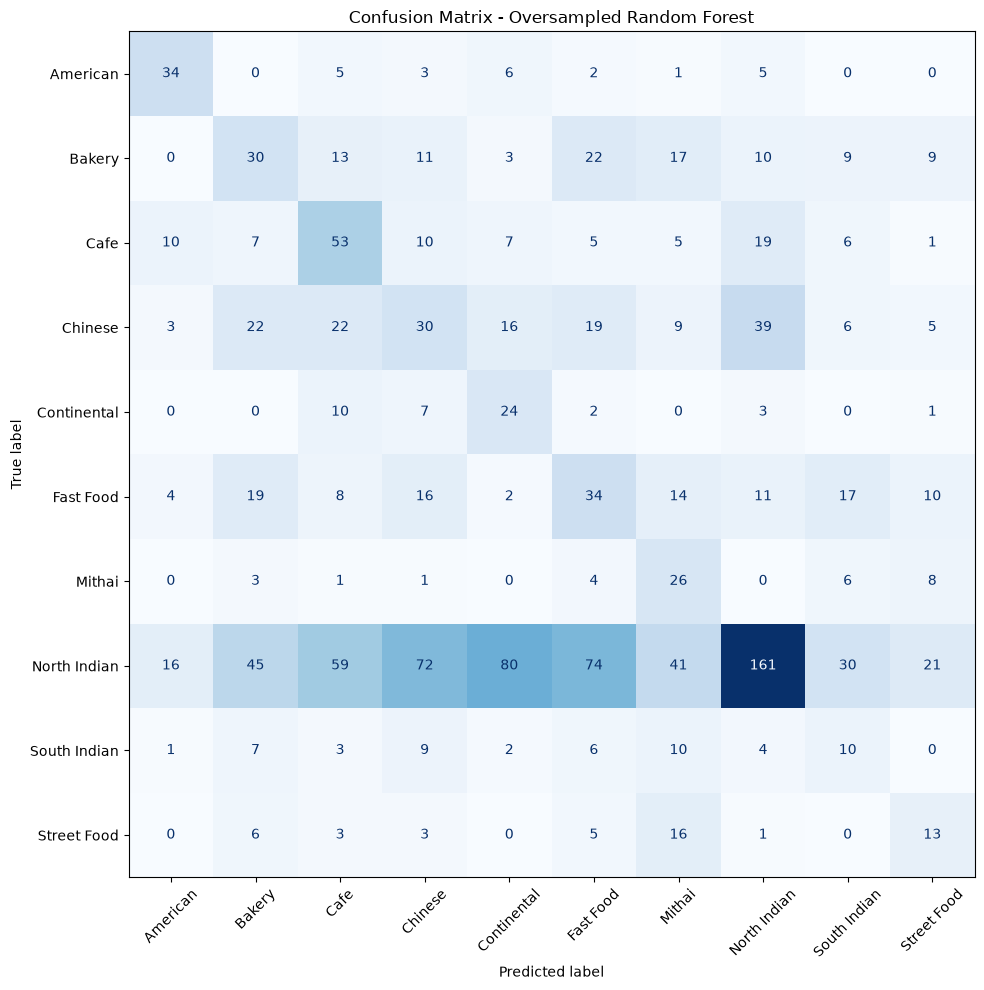

In [45]:

cm_over = confusion_matrix(
    y_test_cuisine,
    y_pred_over,
    labels=oversampled_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_over,
    display_labels=oversampled_model.classes_
)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Oversampled Random Forest")
plt.tight_layout()
plt.show()